# Predictive Log Anomaly Engine — End-to-End Demo

**Pipeline:** Raw Logs → Template Mining → Sequence Windows → Feature Extraction → Anomaly Scoring → Risk Normalization → Alert Policy

This notebook walks through each stage on a **tiny synthetic dataset** (10 log lines from two services).
No external files are read, no models are downloaded, and the notebook runs in under 5 seconds.
All logic mirrors the production code in `src/runtime/` and `src/alerts/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Check if sklearn is available
try:
    from sklearn.ensemble import IsolationForest
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

print(f'sklearn available: {SKLEARN_AVAILABLE}')
print('All imports OK.')

sklearn available: True
All imports OK.


## 1. Demo Logs

Ten synthetic log lines from two services: a **web server** (mostly normal) and a **database** (with injected anomalies).
Each row has a timestamp, service name, message, and a ground-truth label (`0`=normal, `1`=anomaly).

In [2]:
# Sample log data
RAW_LOGS = [
    # (timestamp,          service,    message,                                    label)
    ('2026-03-04 10:00:01', 'web',     'GET /api/health HTTP/1.1 200',             0),
    ('2026-03-04 10:00:02', 'web',     'GET /api/users HTTP/1.1 200',              0),
    ('2026-03-04 10:00:03', 'db',      'Connection established from 10.0.0.5',     0),
    ('2026-03-04 10:00:04', 'db',      'Query executed in 12ms SELECT users',      0),
    ('2026-03-04 10:00:05', 'web',     'GET /api/health HTTP/1.1 200',             0),
    ('2026-03-04 10:00:06', 'db',      'ERROR: connection timeout after 30000ms',  1),
    ('2026-03-04 10:00:07', 'db',      'FATAL: max connections exceeded 500/500',  1),
    ('2026-03-04 10:00:08', 'web',     'POST /api/login HTTP/1.1 401 FAILED',      1),
    ('2026-03-04 10:00:09', 'web',     'POST /api/login HTTP/1.1 401 FAILED',      1),
    ('2026-03-04 10:00:10', 'db',      'Query executed in 14ms SELECT orders',     0),
]

# Create DataFrame from raw logs
df_logs = pd.DataFrame(RAW_LOGS, columns=['timestamp', 'service', 'message', 'label'])
df_logs['label_text'] = df_logs['label'].map({0: 'normal', 1: 'ANOMALY'})

# Display logs with full message text
pd.set_option('display.max_colwidth', 50)
df_logs[['timestamp', 'service', 'message', 'label_text']]

,timestamp,service,message,label_text
0,2026-03-04 10:00:01,web,GET /api/health HTTP/1.1 200,normal
1,2026-03-04 10:00:02,web,GET /api/users HTTP/1.1 200,normal
2,2026-03-04 10:00:03,db,Connection established from 10.0.0.5,normal
3,2026-03-04 10:00:04,db,Query executed in 12ms SELECT users,normal
4,2026-03-04 10:00:05,web,GET /api/health HTTP/1.1 200,normal
5,2026-03-04 10:00:06,db,ERROR: connection timeout after 30000ms,ANOMALY
6,2026-03-04 10:00:07,db,FATAL: max connections exceeded 500/500,ANOMALY
7,2026-03-04 10:00:08,web,POST /api/login HTTP/1.1 401 FAILED,ANOMALY
8,2026-03-04 10:00:09,web,POST /api/login HTTP/1.1 401 FAILED,ANOMALY
9,2026-03-04 10:00:10,db,Query executed in 14ms SELECT orders,normal


## 2. Tokenization — Template Mining

A **template miner** normalizes log messages by substituting variable parts (IPs, numbers, durations)
with typed placeholders (`<IP>`, `<NUM>`, `<DUR>`, …).
Each unique template is assigned an integer **token ID**, reducing the open vocabulary to a compact set.

In [3]:
# Template mining — simplified 5-step regex-based approach
def mine_template(msg: str) -> str:
    """Simplified 5-step regex template miner."""
    msg = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', '<IP>',     msg)
    msg = re.sub(r'\b\d+ms\b',                                '<DUR>',   msg)
    msg = re.sub(r'\b\d+/\d+\b',                              '<RATIO>', msg)
    msg = re.sub(r'\b\d{3}\b',                                '<STATUS>',msg)
    msg = re.sub(r'\b\d+\b',                                  '<NUM>',   msg)
    msg = re.sub(r'\s+',                                       ' ',       msg).strip()
    return msg

# Apply template mining to all messages and assign token IDs
templates = {}
token_ids = []
for msg in df_logs['message']:
    tmpl = mine_template(msg)
    if tmpl not in templates:
        templates[tmpl] = len(templates)
    token_ids.append(templates[tmpl])

df_logs['template'] = [mine_template(m) for m in df_logs['message']]
df_logs['token_id'] = token_ids

# Reverse map — used by frequency plot and e2e trace
id2tmpl = {v: k for k, v in templates.items()}

# Create vocabulary DataFrame
vocab_df = pd.DataFrame(
    [(tid, tmpl) for tmpl, tid in templates.items()],
    columns=['token_id', 'template']
).sort_values('token_id').reset_index(drop=True)

print(f'Vocabulary size: {len(vocab_df)} templates')
vocab_df

Vocabulary size: 8 templates


,token_id,template
0,0,GET /api/health HTTP/<NUM>.<NUM> <STATUS>
1,1,GET /api/users HTTP/<NUM>.<NUM> <STATUS>
2,2,Connection established from <IP>
3,3,Query executed in <DUR> SELECT users
4,4,ERROR: connection timeout after <DUR>
5,5,FATAL: max connections exceeded <RATIO>
6,6,POST /api/login HTTP/<NUM>.<NUM> <STATUS> FAILED
7,7,Query executed in <DUR> SELECT orders


In [4]:
df_logs[['timestamp', 'service', 'token_id', 'template', 'label_text']]

,timestamp,service,token_id,template,label_text
0,2026-03-04 10:00:01,web,0,GET /api/health HTTP/<NUM>.<NUM> <STATUS>,normal
1,2026-03-04 10:00:02,web,1,GET /api/users HTTP/<NUM>.<NUM> <STATUS>,normal
2,2026-03-04 10:00:03,db,2,Connection established from <IP>,normal
3,2026-03-04 10:00:04,db,3,Query executed in <DUR> SELECT users,normal
4,2026-03-04 10:00:05,web,0,GET /api/health HTTP/<NUM>.<NUM> <STATUS>,normal
5,2026-03-04 10:00:06,db,4,ERROR: connection timeout after <DUR>,ANOMALY
6,2026-03-04 10:00:07,db,5,FATAL: max connections exceeded <RATIO>,ANOMALY
7,2026-03-04 10:00:08,web,6,POST /api/login HTTP/<NUM>.<NUM> <STATUS> FAILED,ANOMALY
8,2026-03-04 10:00:09,web,6,POST /api/login HTTP/<NUM>.<NUM> <STATUS> FAILED,ANOMALY
9,2026-03-04 10:00:10,db,7,Query executed in <DUR> SELECT orders,normal


## 3. Template Frequency Distribution

How often does each template appear across all 10 demo log lines?
Red bars indicate templates that appear in at least one anomalous event — useful for spotting which patterns carry risk signal.

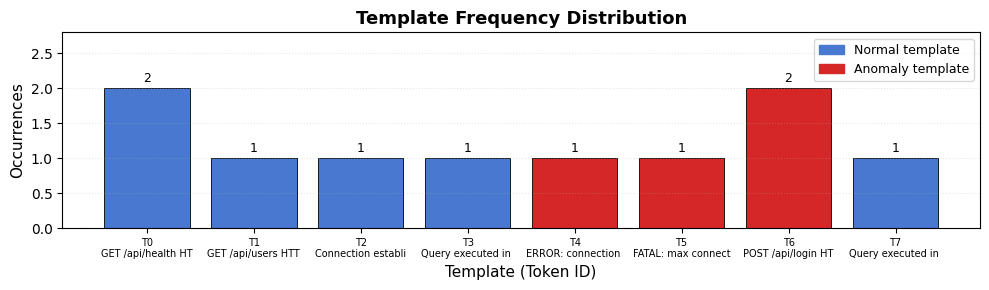

In [5]:
# Template frequency distribution with anomaly highlighting
freq = df_logs['token_id'].value_counts().sort_index()
token_is_anomaly = df_logs.groupby('token_id')['label'].max()
bar_colors = ['#d62728' if token_is_anomaly.get(i, 0) == 1 else '#4878d0'
              for i in freq.index]

# Plotting
fig_freq, ax_freq = plt.subplots(figsize=(10, 3))
bars = ax_freq.bar(range(len(freq)), freq.values,
                   color=bar_colors, edgecolor='black', linewidth=0.6)

# Add count labels on top of bars
for bar, count in zip(bars, freq.values):
    ax_freq.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 str(count), ha='center', va='bottom', fontsize=9)

# Customize axes and labels
ax_freq.set_xticks(range(len(freq)))
ax_freq.set_xticklabels(
    [f'T{i}\n{id2tmpl.get(i,"")[:18]}' for i in freq.index],
    fontsize=7
)
ax_freq.set_xlabel('Template (Token ID)', fontsize=11)
ax_freq.set_ylabel('Occurrences', fontsize=11)
ax_freq.set_title('Template Frequency Distribution', fontsize=13, fontweight='bold')
ax_freq.set_ylim(0, freq.max() + 0.8)
ax_freq.grid(axis='y', alpha=0.3, linestyle=':')

# Create custom legend
legend_patches = [
    mpatches.Patch(color='#4878d0', label='Normal template'),
    mpatches.Patch(color='#d62728', label='Anomaly template'),
]
ax_freq.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Sliding Window Sequences

Events are grouped by `service` and fed through a **sliding window** (`window_size=3`, `stride=1`).
With 5 events per service and a window of 3, this produces **3 windows per service** — enough variety to show the scorer
distinguishing normal from anomalous contexts.
Each window's label is `1` if **any** event inside it is anomalous.

In [6]:
# Create sliding windows of events per service
WINDOW_SIZE = 3
STRIDE = 1

# Build windows of events for a given list of (token_id, label) tuples
def build_windows(events, window_size=3, stride=1):
    windows = []
    for start in range(0, len(events) - window_size + 1, stride):
        chunk = events[start : start + window_size]
        tokens = [e[0] for e in chunk]
        labels = [e[1] for e in chunk]
        windows.append({
            'window_idx':    len(windows),
            'tokens':        tokens,
            'any_anomaly':   int(any(l == 1 for l in labels)),
            'anomaly_count': sum(labels),
        })
    return windows

# Build windows for each service and combine into a single DataFrame
all_windows = []
for service, grp in df_logs.groupby('service', sort=False):
    events = list(zip(grp['token_id'], grp['label']))
    wins = build_windows(events, WINDOW_SIZE, STRIDE)
    for w in wins:
        w['service'] = service
    all_windows.extend(wins)

# Create DataFrame of windows
df_windows = pd.DataFrame(all_windows).reset_index(drop=True)
print(f'Total windows: {len(df_windows)}  (window_size={WINDOW_SIZE}, stride={STRIDE})')
df_windows[['service', 'tokens', 'anomaly_count', 'any_anomaly']]

Total windows: 6  (window_size=3, stride=1)


,service,tokens,anomaly_count,any_anomaly
0,web,"[0, 1, 0]",0,0
1,web,"[1, 0, 6]",1,1
2,web,"[0, 6, 6]",2,1
3,db,"[2, 3, 4]",1,1
4,db,"[3, 4, 5]",2,1
5,db,"[4, 5, 7]",2,1


## 5. Anomaly Scoring

Each window's token sequence is converted into a **feature vector**: token frequency counts + Shannon entropy.
An **IsolationForest** (or a deterministic mock if sklearn is absent) assigns a raw anomaly score.
The model is fitted unsupervised on all windows — no labels are used during training.

In [7]:
# Feature extraction for anomaly scoring
VOCAB_SIZE = len(vocab_df)

# Simple feature extractor: token frequency counts + Shannon entropy
def window_to_features(tokens):
    """Token frequency counts + Shannon entropy."""
    counts = np.zeros(VOCAB_SIZE, dtype=np.float32)
    for t in tokens:
        if 0 <= t < VOCAB_SIZE:
            counts[t] += 1
    total = counts.sum() or 1.0
    freqs = counts / total
    entropy = float(-np.sum(freqs[freqs > 0] * np.log2(freqs[freqs > 0])))
    return np.append(counts, entropy)

# Build feature matrix for all windows
X = np.array([window_to_features(row['tokens']) for _, row in df_windows.iterrows()])
print(f'Feature matrix shape: {X.shape}  ({X.shape[0]} windows x {X.shape[1]} features)')

# Anomaly scoring using Isolation Forest (if sklearn is available) or a simple deterministic method
if SKLEARN_AVAILABLE:
    iso = IsolationForest(n_estimators=50, contamination=0.3, random_state=42)
    iso.fit(X)
    raw_scores = -iso.score_samples(X)
    method = 'IsolationForest (sklearn)'
else:
    token_counts = X[:, :VOCAB_SIZE].sum(axis=0)
    rare_mask = (token_counts <= 1).astype(float)
    raw_scores = X[:, :VOCAB_SIZE].dot(rare_mask) + X[:, -1]
    method = 'Deterministic mock (no sklearn)'

# Add raw anomaly scores to windows DataFrame and display score range
df_windows['raw_score'] = raw_scores
print(f'Scoring method : {method}')
print(f'Score range    : [{raw_scores.min():.4f}, {raw_scores.max():.4f}]')

Feature matrix shape: (6, 9)  (6 windows x 9 features)
Scoring method : IsolationForest (sklearn)
Score range    : [0.4365, 0.5239]


## 6. Risk Score Normalization

Raw scores are min-max normalized to **[0, 1]** — the **risk score**.
A score near 1.0 means the window looks highly anomalous relative to all observed windows.
This keeps the alert threshold consistent regardless of the model's absolute score scale.

In [8]:
# Min-max normalize raw scores to [0, 1] range for better interpretability
def min_max_normalize(arr):
    lo, hi = arr.min(), arr.max()
    if hi == lo:
        return np.full_like(arr, 0.5)
    return (arr - lo) / (hi - lo)

# Add normalized risk scores to DataFrame
df_windows['risk_score'] = min_max_normalize(raw_scores)

summary = df_windows[['service', 'tokens', 'any_anomaly', 'raw_score', 'risk_score']].copy()
summary['risk_score'] = summary['risk_score'].round(3)
summary['raw_score']  = summary['raw_score'].round(4)
summary

,service,tokens,any_anomaly,raw_score,risk_score
0,web,"[0, 1, 0]",0,0.4836,0.539
1,web,"[1, 0, 6]",1,0.4525,0.182
2,web,"[0, 6, 6]",1,0.4861,0.567
3,db,"[2, 3, 4]",1,0.5239,1.000
4,db,"[3, 4, 5]",1,0.4365,0.000
5,db,"[4, 5, 7]",1,0.4911,0.625


## 7. Alert Policy

An alert fires when `risk_score >= threshold` AND no alert was fired for this service within the last `cooldown` windows.
Severity is classified by how far the score exceeds the threshold: `CRITICAL (1.8x)` / `HIGH (1.4x)` / `MEDIUM (1.0x)`.

In [9]:
# Simple threshold-based alerting with cooldown and severity classification
THRESHOLD    = 0.5
COOLDOWN_WIN = 2

# Classify severity based on risk-to-threshold ratio
def classify_severity(risk, thr):
    ratio = risk / thr if thr > 0 else 0
    if ratio >= 1.8: return 'CRITICAL'
    if ratio >= 1.4: return 'HIGH'
    if ratio >= 1.0: return 'MEDIUM'
    return 'none'

last_alert_win = {}
decisions = []

# Simulate alerting logic over windows, applying threshold, cooldown, and severity classification
for _, row in df_windows.iterrows():
    svc   = row['service']
    widx  = row['window_idx']
    risk  = row['risk_score']
    above = risk >= THRESHOLD

    in_cooldown = svc in last_alert_win and (widx - last_alert_win[svc]) <= COOLDOWN_WIN
    fires = above and not in_cooldown
    if fires:
        last_alert_win[svc] = widx

    # Record decision for this window
    decisions.append({
        'win_id':      widx,
        'service':     svc,
        'risk_score':  round(risk, 3),
        'above_thr':   above,
        'in_cooldown': in_cooldown,
        'alert_fires': fires,
        'severity':    classify_severity(risk, THRESHOLD) if fires else 'none',
        'true_label':  row['any_anomaly'],
    })

# Create DataFrame of decisions and summarize alerting performance
df_decisions = pd.DataFrame(decisions)
print(f'Threshold : {THRESHOLD}   |   '
      f'Alerts fired: {df_decisions["alert_fires"].sum()} / {len(df_decisions)} windows')
df_decisions

Threshold : 0.5   |   Alerts fired: 2 / 6 windows


,win_id,service,risk_score,above_thr,in_cooldown,alert_fires,severity,true_label
0,0,web,0.539,True,False,True,MEDIUM,0
1,1,web,0.182,False,True,False,none,1
2,2,web,0.567,True,True,False,none,1
3,0,db,1.000,True,False,True,CRITICAL,1
4,1,db,0.000,False,True,False,none,1
5,2,db,0.625,True,True,False,none,1


## 8. End-to-End Trace

This trace shows how a **single window** is transformed from raw tokens into model features
and finally into an alert decision — connecting every pipeline stage in one view.
The window selected is the first one that fired an alert (or the highest-risk window if no alert fired).

In [10]:
# End-to-end trace for a specific window (preferably one that fired an alert, otherwise the highest risk score)
alert_rows = df_decisions[df_decisions['alert_fires']]
highlight_win = int(alert_rows.iloc[0]['win_id']) if not alert_rows.empty \
    else int(df_windows['risk_score'].idxmax())

# Extract relevant rows and data for the highlighted window
win_row  = df_windows.loc[highlight_win]
dec_row  = df_decisions[df_decisions['win_id'] == win_row['window_idx']].iloc[0]
tok_list = win_row['tokens']

print('=' * 62)
print('  END-TO-END TRACE')
print('=' * 62)
print(f'Service    : {win_row["service"]}')
print(f'Window ID  : {highlight_win}  ({len(tok_list)} events)\n')
print('STEP 1 - Tokens in window:')
for idx, tid in enumerate(tok_list):
    print(f'  [{idx}] token_id={tid}  template: {id2tmpl.get(tid, "?")}')

# Extract features for this window and display key values
features = window_to_features(tok_list)
print(f'\nSTEP 2 - Feature shape: {features.shape}')
print(f'         Non-zero dims : {int((features[:VOCAB_SIZE] > 0).sum())}')
print(f'         Entropy       : {features[-1]:.4f}')
print(f'\nSTEP 3 - Raw score   : {win_row["raw_score"]:.4f}')
print(f'STEP 4 - Risk score  : {win_row["risk_score"]:.3f}  (0=normal, 1=anomalous)')
print(f'\nSTEP 5 - Above thr   : {dec_row["above_thr"]}')
print(f'         In cooldown  : {dec_row["in_cooldown"]}')
print(f'         Alert fires  : {dec_row["alert_fires"]}')
print(f'         Severity     : {dec_row["severity"]}')
print(f'         True label   : {"ANOMALY" if dec_row["true_label"] else "normal"}')
print('=' * 62)

  END-TO-END TRACE
Service    : web
Window ID  : 0  (3 events)

STEP 1 - Tokens in window:
  [0] token_id=0  template: GET /api/health HTTP/<NUM>.<NUM> <STATUS>
  [1] token_id=1  template: GET /api/users HTTP/<NUM>.<NUM> <STATUS>
  [2] token_id=0  template: GET /api/health HTTP/<NUM>.<NUM> <STATUS>

STEP 2 - Feature shape: (9,)
         Non-zero dims : 2
         Entropy       : 0.9183

STEP 3 - Raw score   : 0.4836
STEP 4 - Risk score  : 0.539  (0=normal, 1=anomalous)

STEP 5 - Above thr   : True
         In cooldown  : False
         Alert fires  : True
         Severity     : MEDIUM
         True label   : normal


## 9. Risk Score Plot

Risk score for every window, coloured by alert severity.
The dashed red line is the alert threshold; **X** marks windows that contain at least one truly anomalous event.

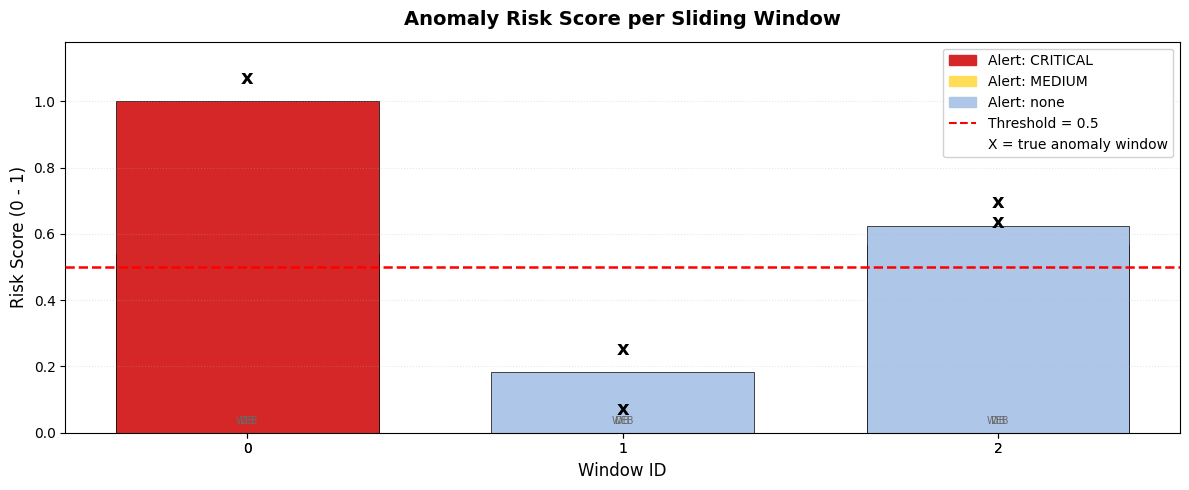

In [11]:
COLORS = {
    'CRITICAL': '#d62728',
    'HIGH':     '#ff7f0e',
    'MEDIUM':   '#ffdd57',
    'none':     '#aec7e8',
}

# Visualize risk scores per window with alerting decisions and true labels
fig, ax = plt.subplots(figsize=(12, 5))

for _, row in df_decisions.iterrows():
    color = COLORS.get(row['severity'], '#aec7e8')
    ax.bar(row['win_id'], row['risk_score'], color=color,
           edgecolor='black', linewidth=0.5, width=0.7)

# Threshold line
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.8, zorder=5)

# X markers on true anomaly windows; service label at base
for _, row in df_decisions.iterrows():
    if row['true_label'] == 1:
        ax.annotate('x', xy=(row['win_id'], row['risk_score'] + 0.04),
                    ha='center', va='bottom', fontsize=14,
                    color='black', fontweight='bold')
    ax.text(row['win_id'], 0.02, row['service'][:3].upper(),
            ha='center', va='bottom', fontsize=7, color='dimgrey')

# Legend: only show severity colours that actually appear
present_sevs = df_decisions['severity'].unique()
patches = [mpatches.Patch(color=COLORS[s], label=f'Alert: {s}')
           for s in ['CRITICAL', 'HIGH', 'MEDIUM', 'none'] if s in present_sevs]
patches.append(plt.Line2D([0], [0], color='red', linestyle='--',
                           label=f'Threshold = {THRESHOLD}'))
patches.append(mpatches.Patch(color='white', label='X = true anomaly window'))
ax.legend(handles=patches, loc='upper right', fontsize=10, framealpha=0.9)

ax.set_xlabel('Window ID', fontsize=12)
ax.set_ylabel('Risk Score (0 - 1)', fontsize=12)
ax.set_title('Anomaly Risk Score per Sliding Window',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, 1.18)
ax.set_xticks(df_decisions['win_id'])
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

## Demo Summary

- **Logs are converted into templates and tokens** — a regex-based miner abstracts variable parts (IPs, numbers, durations) into typed placeholders, shrinking the vocabulary from millions of strings to a compact fixed set.
- **Event windows capture system behavior patterns** — grouping consecutive tokens into sliding windows lets the model reason about sequences of events rather than individual lines, surfacing context-dependent anomalies.
- **An anomaly model produces a risk score used by the alert policy** — IsolationForest scores each window, min-max normalization maps the score to [0, 1], and the alert policy applies a threshold and per-stream cooldown to fire severity-classified alerts.